<a href="https://colab.research.google.com/github/yassmin1/Learn_ML/blob/main/06_classification_threshold_responsible.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Choosing a Classification Threshold Responsibly

## A one-hour statistics and data science learning session

**Central question:** A college has developed a machine-learning model that predicts which students may need academic support. The model assigns every student a risk score between 0 and 1. At what score should the college contact a student?

This notebook teaches more than formulas. Students calculate classification metrics, examine trade-offs, challenge assumptions, evaluate AI feedback, consider fairness, and make a defensible recommendation.

> **Learning principle:** AI may challenge the learner's reasoning, but it should not make the final decision.

## Learning objectives

By the end of the session, students should be able to:

- explain how a classification threshold changes model predictions;
- distinguish true positives, false positives, true negatives, and false negatives;
- calculate and interpret precision, recall, accuracy, and specificity;
- compare the human consequences of different model errors;
- choose a threshold based on purpose, context, and available resources;
- identify missing evidence in a model-evaluation report;
- use AI as a critical reviewer rather than an answer generator;
- communicate a recommendation to technical and nontechnical audiences;
- recognize that strong model performance does not automatically justify deployment.

## Suggested one-hour schedule

| Time | Activity |
|---|---|
| 0–7 minutes | Examine the decision before learning formulas |
| 7–15 minutes | Build and interpret a confusion matrix |
| 15–23 minutes | Calculate precision, recall, accuracy, and specificity |
| 23–31 minutes | Make an initial recommendation |
| 31–39 minutes | Use AI as a critical reviewer |
| 39–47 minutes | Examine fairness and missing evidence |
| 47–54 minutes | Revise the recommendation |
| 54–58 minutes | Transfer the reasoning to a healthcare case |
| 58–60 minutes | Complete an exit reflection |

# Part 1 — Think Before Calculating

The model produces a score from **0 to 1**. Students scoring at or above the selected threshold will receive an outreach message offering tutoring, advising, or other support.

Before running any code, respond to these questions:

1. Where would you initially place the threshold?
2. Which mistake seems more serious: contacting a student who does not need support, or missing a student who does?
3. Could an unnecessary support message create harm?
4. What information would you need before choosing a threshold?
5. Who should participate in this decision?

### My initial position

**Initial threshold:**  

**Reason:**  

**The error I consider more serious:**  

**Information still needed:**  

**People who should participate in the decision:**

# Part 2 — Understand the Four Outcomes

| Outcome | Plain-language meaning |
|---|---|
| **True positive (TP)** | A student needed support and was contacted |
| **False positive (FP)** | A student did not need support but was contacted |
| **True negative (TN)** | A student did not need support and was not contacted |
| **False negative (FN)** | A student needed support but was not contacted |

The words *positive* and *negative* refer to the model prediction, not whether the outcome is morally good or bad.

## Two candidate thresholds

### Threshold A: 0.30

| Outcome | Number of students |
|---|---:|
| True positives | 8 |
| False positives | 12 |
| True negatives | 18 |
| False negatives | 2 |

### Threshold B: 0.60

| Outcome | Number of students |
|---|---:|
| True positives | 5 |
| False positives | 3 |
| True negatives | 27 |
| False negatives | 5 |

Before using formulas, describe the practical difference between these thresholds in your own words.

### My interpretation

**Threshold 0.30:**  

**Threshold 0.60:**  

**Main trade-off:**

# Part 3 — Calculate the Metrics

- **Precision:** Among students contacted, how many actually needed support?
- **Recall:** Among students who needed support, how many were contacted?
- **Accuracy:** Among all students, how many were classified correctly?
- **Specificity:** Among students who did not need support, how many were correctly left unflagged?

In [ ]:
def classification_metrics(tp, fp, tn, fn):
    total = tp + fp + tn + fn
    return {
        "Precision": tp / (tp + fp) if (tp + fp) else 0,
        "Recall": tp / (tp + fn) if (tp + fn) else 0,
        "Accuracy": (tp + tn) / total if total else 0,
        "Specificity": tn / (tn + fp) if (tn + fp) else 0,
    }

threshold_a = classification_metrics(tp=8, fp=12, tn=18, fn=2)
threshold_b = classification_metrics(tp=5, fp=3, tn=27, fn=5)

threshold_a, threshold_b

({'Precision': 0.4, 'Recall': 0.8, 'Accuracy': 0.65, 'Specificity': 0.6},
 {'Precision': 0.625, 'Recall': 0.5, 'Accuracy': 0.8, 'Specificity': 0.9})

In [ ]:
import pandas as pd

comparison = pd.DataFrame(
    [threshold_a, threshold_b],
    index=["Threshold 0.30", "Threshold 0.60"]
)
comparison.style.format("{:.1%}")

,Precision,Recall,Accuracy,Specificity
Threshold 0.30,40.0%,80.0%,65.0%,60.0%
Threshold 0.60,62.5%,50.0%,80.0%,90.0%


### Interpret the results

- Threshold 0.30 has higher ____________, which means ______________________________.
- Threshold 0.60 has higher ____________, which means ______________________________.
- The preferred threshold depends on ______________________________________________.

<details>
<summary><strong>Reveal a possible interpretation</strong></summary>

Threshold 0.30 has higher recall, so it identifies more students who need support, but it also contacts more students who may not need it.

Threshold 0.60 has higher precision and specificity, but it misses half of the students who need support.

Neither threshold is universally best. The choice depends on the purpose of the intervention, advising capacity, the consequences of each error, the design of the outreach, and fairness across groups.

</details>

# Part 4 — Explore Thresholds With Student-Level Data

The following fictional dataset contains 40 students. Each student has a model-generated risk score and an observed outcome showing whether the student actually needed support.

In [ ]:
import numpy as np

positive_scores = [0.95, 0.87, 0.79, 0.72, 0.64, 0.56, 0.48, 0.35, 0.22, 0.12]
negative_scores = [
    0.90, 0.74, 0.63,
    0.58, 0.54, 0.51, 0.46, 0.43, 0.39, 0.36, 0.34, 0.31,
    0.29, 0.27, 0.25, 0.23, 0.21, 0.19, 0.18, 0.16, 0.15,
    0.14, 0.13, 0.11, 0.10, 0.09, 0.08, 0.07, 0.05, 0.03
]

students = pd.DataFrame({
    "student_id": [f"S{i:02d}" for i in range(1, 41)],
    "risk_score": positive_scores + negative_scores,
    "actually_needed_support": [1] * 10 + [0] * 30,
}).sample(frac=1, random_state=42).reset_index(drop=True)

students.head(10)

,student_id,risk_score,actually_needed_support
0,S20,0.36,0
1,S17,0.46,0
2,S16,0.51,0
3,S27,0.21,0
4,S05,0.64,1
5,S13,0.63,0
6,S38,0.07,0
7,S28,0.19,0
8,S40,0.03,0
9,S07,0.48,1


In [ ]:
def evaluate_threshold(data, threshold):
    df = data.copy()
    df["predicted_need"] = (df["risk_score"] >= threshold).astype(int)

    tp = ((df["predicted_need"] == 1) & (df["actually_needed_support"] == 1)).sum()
    fp = ((df["predicted_need"] == 1) & (df["actually_needed_support"] == 0)).sum()
    tn = ((df["predicted_need"] == 0) & (df["actually_needed_support"] == 0)).sum()
    fn = ((df["predicted_need"] == 0) & (df["actually_needed_support"] == 1)).sum()

    metrics = classification_metrics(tp, fp, tn, fn)
    metrics.update({
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Students contacted": tp + fp,
    })
    return metrics

pd.DataFrame([
    evaluate_threshold(students, 0.30),
    evaluate_threshold(students, 0.60),
]).set_index("Threshold")

,Precision,Recall,Accuracy,Specificity,TP,FP,TN,FN,Students contacted
Threshold,,,,,,,,,
0.3,0.400,0.8,0.65,0.6,8,12,18,2,20
0.6,0.625,0.5,0.80,0.9,5,3,27,5,8


## Try your own threshold

Change the value below and rerun the cell. Observe how the confusion-matrix counts, metrics, and advising workload change.

In [ ]:
chosen_threshold = 0.45  # Change this value between 0 and 1
pd.Series(evaluate_threshold(students, chosen_threshold))

Precision              0.500000
Recall                 0.700000
Accuracy               0.750000
Specificity            0.766667
Threshold              0.450000
TP                     7.000000
FP                     7.000000
TN                    23.000000
FN                     3.000000
Students contacted    14.000000
dtype: float64

Test at least three thresholds.

| Threshold | Precision | Recall | Students contacted | Main advantage | Main risk |
|---:|---:|---:|---:|---|---|
| | | | | | |
| | | | | | |
| | | | | | |

In [ ]:
thresholds = np.arange(0.05, 1.00, 0.05)
results = pd.DataFrame([evaluate_threshold(students, t) for t in thresholds])
results[["Threshold", "Precision", "Recall", "Accuracy", "Specificity", "Students contacted"]].head()

,Threshold,Precision,Recall,Accuracy,Specificity,Students contacted
0,0.05,0.256410,1.0,0.275,0.033333,39
1,0.10,0.285714,1.0,0.375,0.166667,35
2,0.15,0.310345,0.9,0.475,0.333333,29
3,0.20,0.346154,0.9,0.550,0.433333,26
4,0.25,0.347826,0.8,0.575,0.500000,23


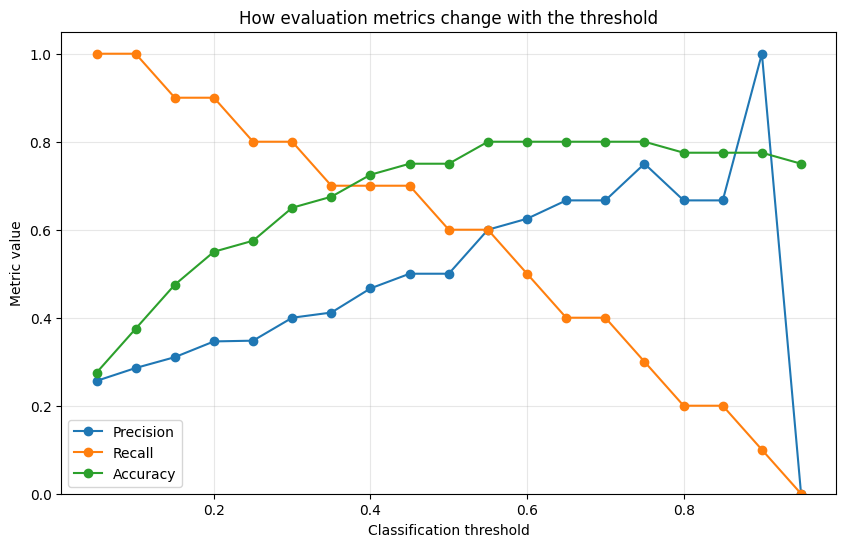

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(results["Threshold"], results["Precision"], marker="o", label="Precision")
plt.plot(results["Threshold"], results["Recall"], marker="o", label="Recall")
plt.plot(results["Threshold"], results["Accuracy"], marker="o", label="Accuracy")
plt.xlabel("Classification threshold")
plt.ylabel("Metric value")
plt.title("How evaluation metrics change with the threshold")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Discussion

1. Why does recall usually decrease as the threshold rises?
2. Why can precision improve as the threshold rises?
3. Does the threshold with the highest accuracy necessarily produce the best intervention?
4. What happens to advising workload as the threshold decreases?
5. What consequences are not visible in the chart?

# Part 5 — Make an Initial Recommendation

Choose one position:

- Use a threshold of 0.30
- Use a threshold of 0.60
- Recommend another threshold
- Do not deploy the model yet

Include the threshold or action, the metric that influenced you most, the cost of each error, one assumption, and one limitation.

### Initial recommendation

**Recommendation:**  

**Most important metric:**  

**Cost of false positives:**  

**Cost of false negatives:**  

**Assumption:**  

**Limitation:**

# Part 6 — Use AI as a Critical Reviewer

Do **not** ask AI to choose the threshold.

Choose one prompt:

> We selected a threshold of ___ because ___. Ask us four questions that could expose weaknesses in our decision. Do not choose a threshold for us.

> Act as a college advisor with limited time. Present the strongest objection to our recommendation.

> Identify two assumptions we may be making about false positives and false negatives.

> What additional data should we request before approving this model for student outreach?

> Present a reasonable argument for the threshold we rejected.

## Evaluate the AI response

**Prompt used:**  

**One useful point:**  

**One claim requiring verification:**  

**One unsupported assumption:**  

**One weak or irrelevant suggestion:**  

**One idea I will use:**  

**One idea I will reject and why:**

# Part 7 — Examine Fairness and Missing Evidence

Overall performance can hide important differences.

| Student group | Students who needed support | Correctly identified | Recall |
|---|---:|---:|---:|
| Group 1 | 20 | 17 | 85% |
| Group 2 | 20 | 11 | 55% |

This difference is a warning sign requiring investigation. It is not, by itself, a complete explanation of why the difference exists.

In [ ]:
fairness = pd.DataFrame({
    "Group": ["Group 1", "Group 2"],
    "Students who needed support": [20, 20],
    "Correctly identified": [17, 11],
})
fairness["Recall"] = fairness["Correctly identified"] / fairness["Students who needed support"]
fairness.style.format({"Recall": "{:.1%}"})

,Group,Students who needed support,Correctly identified,Recall
0,Group 1,20,17,85.0%
1,Group 2,20,11,55.0%


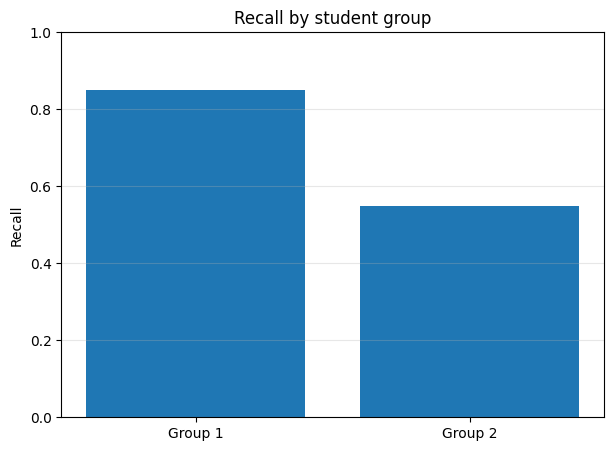

In [ ]:
plt.figure(figsize=(7, 5))
plt.bar(fairness["Group"], fairness["Recall"])
plt.ylim(0, 1)
plt.ylabel("Recall")
plt.title("Recall by student group")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Fairness discussion

1. Is strong overall recall enough to approve the model?
2. What could explain the difference between groups?
3. Does the difference automatically prove discrimination?
4. What additional analysis is needed?
5. Should the same threshold always be used for every group?
6. What risks arise from group-specific thresholds?
7. Who should review the model before deployment?
8. How should students be informed that a predictive system is being used?

# Part 8 — Revise the Recommendation

Address four dimensions:

### 1. Technical recommendation
Which threshold should be tested or used, and why?

### 2. Operational recommendation
Can the college support the number of students who will be contacted?

### 3. Fairness recommendation
What subgroup testing, data review, or monitoring is required?

### 4. Human-oversight recommendation
Which decisions should remain with advisors rather than being automated?

<details>
<summary><strong>Reveal an example of a well-reasoned recommendation</strong></summary>

We recommend piloting a relatively low threshold because the intervention is an offer of support and missing a struggling student may be more harmful than sending an unnecessary invitation. However, the model should not assign a permanent label, restrict opportunities, or trigger an automatic academic decision.

Before broader deployment, the college should investigate group differences, review data quality and outcome definitions, and confirm that advising capacity is sufficient. The threshold should be monitored after deployment because student behavior, services, and model performance may change over time.

The model should support advisor judgment rather than replace it.

</details>

# Part 9 — Transfer the Reasoning

Complete this activity **without AI**.

A hospital model predicts which patients may require an urgent follow-up appointment.

- At a low threshold, the model identifies nearly all high-risk patients but generates many false alarms.
- At a high threshold, alerts are more precise, but more high-risk patients are missed.

Answer:

1. Which error is likely to carry the greater cost?
2. Would you use the same threshold as in the college example?
3. What additional information is required?
4. Why can a threshold that works in one setting be inappropriate in another?
5. What decision must remain under human oversight?

### Transfer response

**More serious error:**  

**Would I use the same threshold? Why or why not?**  

**Additional information needed:**  

**Human-oversight requirement:**

# Part 10 — Exit Reflection

Complete the statements:

- Before this lesson, I thought a classification threshold was …
- The most important trade-off I noticed was …
- The evidence that most changed my thinking was …
- AI helped me examine …
- One AI suggestion I rejected was …
- The final decision should remain with humans because …
- I can now do the following independently …

# Instructor Review Checklist

- [ ] Students formed an initial position before using AI.
- [ ] Students calculated and interpreted metrics rather than copying formulas.
- [ ] Students connected model errors to human consequences.
- [ ] Students compared more than one defensible recommendation.
- [ ] AI was used to critique reasoning rather than supply the final answer.
- [ ] Students verified and evaluated AI output.
- [ ] Fairness was treated as an investigation, not a slogan or single metric.
- [ ] Students transferred the reasoning to a new context.
- [ ] The final task required independent judgment.
- [ ] Reflection made changes in student thinking visible.
- [ ] The teacher guided the process without announcing one universal threshold.

# Closing Principle

A model can assign a risk score, but it cannot decide what a community should value.

The threshold is not merely a technical setting. It represents a choice about which errors matter, whose needs receive attention, what resources are available, and who accepts responsibility for the consequences.

The goal is not to teach students to search for one perfect metric. It is to help them become data scientists who calculate carefully, question assumptions, communicate uncertainty, evaluate evidence, and use models responsibly.